# Iris Flower Classification

In this Notebook we create a Machine Learning Classification model using PyTorch for the Iris Flower Dataset, basically the "hello world" of Machine Learning.

First of all we want to load the dataset from sklearn, then we standardize it and then we split it into train and test (80% train 20% test, in this case), after that we tensorize the X and y of both train and test so that it's PyTorch-ready.

In [180]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data.astype(np.float32)
y = iris.target.astype(np.int64)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)

X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)       # we divide the training dataset into batches and then shuffle them to avoid biases
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Then we create the actual model, a Neural Network that takes in 4 parameters (sepal_length, sepal_width, petal_length, petal_width) and uses the classic linear function ```input * weights + bias``` to create 16 values that go into 16 neurons of the hidden layer, then uses the ReLU activation function to remove any negative number and then uses again the linear function to give out 3 values for the 3 neurons in the output layer.

In [181]:
class IrisClassifier(nn.Module):
    def __init__(self, input_size=4, hidden_size=16, output_size=3):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [182]:
model = IrisClassifier()

print(model)

IrisClassifier(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)


This takes the output nodes and applies the Softmax, which means that the three values are transformed into values that sum up to 1 (probabilities), the higher number is the most likely class of belonging of a given example. Then it calculate the Negative Log Likelihood which means "how low is the probability assigned to the correct class".
Then we take all the biases and weights that the model has to learn, we assign a learning rate of 0.01 (which says how much does the model have to correct its weight at each epoch? exactly of 0.01 of its gradient), for this case we use Adam as the optimizer.

In [183]:
lf = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
epoch_loss = [[],[]]

for epoch in range(epochs):
    model.train()                                       # in this case is useless, but it is a good habit
    running_loss = 0.0

    for X_batch, y_batch in train_loader:               # we use X_batch tensor 16x4 (the flower params) and y_batch 16x1 (the labels)
        outputs = model(X_batch)                        # we obtain a tensor 16x3 with the (raw numbers) for each flower of the batch  
        loss = lf(outputs, y_batch)                     # this calculate the average error on a given flower batch
        optimizer.zero_grad()                           # this way the model actually learn, otherwise the gradients will be summed up across batches
        loss.backward()                                 # this goes across our NN bacward and tells the effect of the learning rate on the loss
        optimizer.step()
        running_loss += loss.item()                     # this calculate the cumulative loss on the entire epoch
        epoch_loss[0].append(epoch + 1)
        epoch_loss[1].append(running_loss/len(train_loader))

    print(f"Epoca {epoch + 1}, Loss {running_loss/len(train_loader):.4f}")

Epoca 1, Loss 0.9346
Epoca 2, Loss 0.6888
Epoca 3, Loss 0.5354
Epoca 4, Loss 0.4712
Epoca 5, Loss 0.3960
Epoca 6, Loss 0.3521
Epoca 7, Loss 0.3101
Epoca 8, Loss 0.2757
Epoca 9, Loss 0.2482
Epoca 10, Loss 0.2285
Epoca 11, Loss 0.1862
Epoca 12, Loss 0.1626
Epoca 13, Loss 0.1352
Epoca 14, Loss 0.1309
Epoca 15, Loss 0.1150
Epoca 16, Loss 0.1000
Epoca 17, Loss 0.0972
Epoca 18, Loss 0.0877
Epoca 19, Loss 0.0830
Epoca 20, Loss 0.0767
Epoca 21, Loss 0.0826
Epoca 22, Loss 0.0881
Epoca 23, Loss 0.0777
Epoca 24, Loss 0.0718
Epoca 25, Loss 0.0727
Epoca 26, Loss 0.0715
Epoca 27, Loss 0.0685
Epoca 28, Loss 0.0677
Epoca 29, Loss 0.0716
Epoca 30, Loss 0.0700
Epoca 31, Loss 0.0606
Epoca 32, Loss 0.0653
Epoca 33, Loss 0.0678
Epoca 34, Loss 0.0591
Epoca 35, Loss 0.0732
Epoca 36, Loss 0.0622
Epoca 37, Loss 0.0598
Epoca 38, Loss 0.0624
Epoca 39, Loss 0.0567
Epoca 40, Loss 0.0544
Epoca 41, Loss 0.0535
Epoca 42, Loss 0.0544
Epoca 43, Loss 0.0540
Epoca 44, Loss 0.0542
Epoca 45, Loss 0.0507
Epoca 46, Loss 0.05

This is the function we use to evaluate the model based on the remaining 20% of the dataset used ONLY for testing.

In [184]:
def eval_model(model, data_loader):
    model.eval()                                        # equivalent for the test phase of the model.train()
    correct = 0
    total = 0

    with torch.no_grad():                               # since we are in testing, we dont need to remember the previous operations and we consume less RAM
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)        # this way we take the class of the higher logit value
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    return correct / total                              # then we return the overall accuracy of the test

accuracy = eval_model(model, test_loader)
print(f"Accuracy {accuracy*100:.2f}")

Accuracy 100.00


Now we use a Confusion Matrix to understand the errors the model makes and we see that the model just made 2 errors

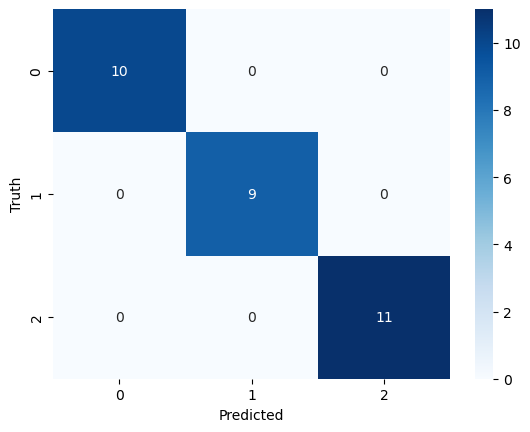

In [185]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

In the end we calculate the confidence of prediction, in this case we can see that in most cases the model has confidence 100% but still predicts correctly for edge cases.

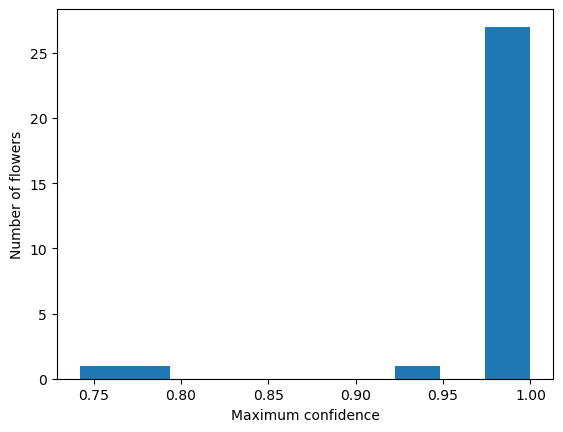

In [186]:
with torch.no_grad():
    outputs = model(X_test_t)
    probs = torch.softmax(outputs, dim=1)
    max_probs, _ = torch.max(probs, 1)

plt.hist(max_probs.numpy(), bins=10)
plt.xlabel('Maximum confidence')
plt.ylabel('Number of flowers')
plt.show()

# we want to see what happens to the confidence when the model makes a mistake

model.eval()
all_preds = []
all_labels = []
all_max_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, 1)
        
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())
        all_max_probs.extend(max_probs.numpy())

for i, (pred, label, prob) in enumerate(zip(all_preds, all_labels, all_max_probs)):
    if pred != label:
        print(f"Flower {i}: Prediction={pred}, Truth={label}, Confidence={prob:.2%}")